In [1]:
import os
import pydicom
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
TARGET_PTID = "941_S_7051"
BASE_SEARCH_DIR = Path("../data/01_raw/ADNI/ADNIAlpha") 
OUTPUT_DIR = Path("../data/08_reporting")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def load_scan(path):
    slices = []
    print(f"Loading scan from: {path}")
    for s in os.listdir(path):
        if s.endswith(".dcm"):
            try:
                ds = pydicom.dcmread(os.path.join(path, s))
                slices.append(ds)
            except Exception:
                pass
    if not slices:
        return []
    
    # Sort by instance number to get 3D order
    try:
        slices.sort(key=lambda x: int(x.InstanceNumber))
    except AttributeError:
        slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
        
    return slices

In [4]:
def find_deepest_dicom_folder(base_path, ptid):
    target_dir = None
    max_files = 0
    for root, dirs, files in os.walk(base_path):
        if ptid in root:
            dcm_count = len([f for f in files if f.endswith(".dcm")])
            if dcm_count > max_files:
                max_files = dcm_count
                target_dir = root
    return target_dir

Loading scan from: ../data/01_raw/ADNI/ADNIAlpha/941_S_7051/Accelerated_Sagittal_MPRAGE__MSV21_/2024-07-03_10_31_31.0/I10873191


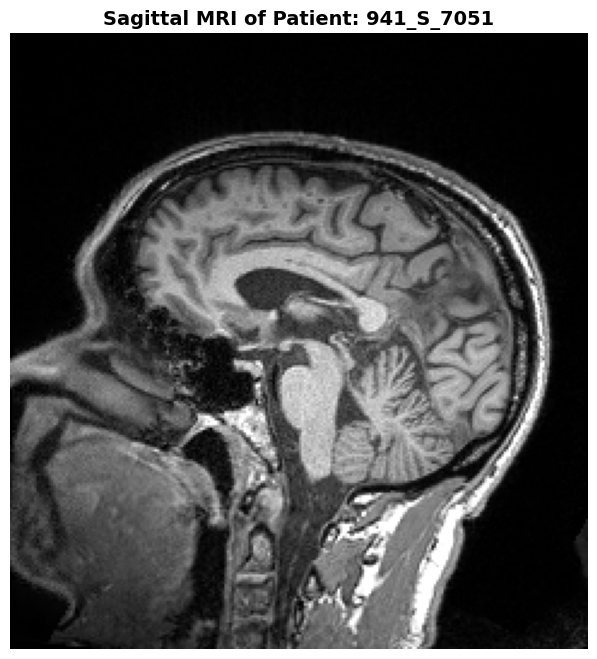

In [5]:
def generate_upright_mri():
    scan_dir = find_deepest_dicom_folder(BASE_SEARCH_DIR, TARGET_PTID)
    if not scan_dir:
        print("ERROR FOR SCAN!")
        return

    slices = load_scan(scan_dir)
    
    # Select middle slice
    mid_idx = len(slices) // 2
    mid_slice = slices[mid_idx].pixel_array
    
    # Rotate 90 degrees counter clockwise but by 4x I think
    corrected_slice = np.rot90(mid_slice, k=4)


    # Contrast enhancement
    vmin = np.percentile(corrected_slice, 1)
    vmax = np.percentile(corrected_slice, 99)

    # Visualize
    plt.figure(figsize=(8, 8))
    plt.imshow(corrected_slice, cmap='gray', vmin=vmin, vmax=vmax)
    
    plt.axis('off')
    plt.title(f"Sagittal MRI of Patient: {TARGET_PTID}", fontsize=14, weight='bold')
    
    save_path = OUTPUT_DIR / "mri_sample_visual.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    generate_upright_mri()